### Instruksi Pengerjaan

Buat notebook baru **`Tugas7_[NPM]_[Nama Lengkap].ipynb`**, lalu bangun pipeline analisis lengkap:


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum, count, avg, row_number
from pyspark.sql.window import Window

# 1. Inisialisasi SparkSession
spark = SparkSession.builder \
    .appName("Tugas7_KopiNusantara") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print("SparkSession berhasil dibuat. Versi:", spark.version)

26/09/24 04:06:28 WARN Utils: Your hostname, Ubuntu24 resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/09/24 04:06:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 04:06:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/24 04:06:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/09/24 04:06:34 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


SparkSession berhasil dibuat. Versi: 3.5.9


**A. EXTRACT** *(bobot 10%)*

Baca ketiga sumber data **dari HDFS** (bukan disk lokal) menjadi tiga Spark DataFrame.


In [2]:
# Membaca data dari HDFS
df_transaksi = spark.read.csv("hdfs://localhost:9000/user/mahasiswa/tugas7/raw/tugas7_transaksi.csv", header=True, inferSchema=True)
df_cabang = spark.read.json("hdfs://localhost:9000/user/mahasiswa/tugas7/raw/tugas7_cabang.json")
df_menu = spark.read.csv("hdfs://localhost:9000/user/mahasiswa/tugas7/raw/tugas7_menu.csv", header=True, inferSchema=True)

# Mengecek sekilas jumlah baris untuk memastikan data terekstrak
print(f"Data Transaksi: {df_transaksi.count()} baris")
print(f"Data Cabang: {df_cabang.count()} baris")
print(f"Data Menu: {df_menu.count()} baris")

Data Transaksi: 4000 baris
Data Cabang: 3 baris
Data Menu: 15 baris


**B. TRANSFORM — Join & Kolom Turunan** *(bobot 20%)*

Gabungkan ketiga tabel, tambahkan kolom `total_penjualan` (`qty x harga`).


In [3]:
# Melakukan inner join antar DataFrame
df_gabungan = df_transaksi.join(df_cabang, on="cabang_id", how="inner") \
                          .join(df_menu, on="menu_id", how="inner")

# Menambahkan kolom turunan 'total_penjualan'
df_gabungan = df_gabungan.withColumn("total_penjualan", col("qty") * col("harga"))

df_gabungan.show(5)

+-------+---------+------+---+--------------+----------+--------------------+---------+--------------+-----+---------------+
|menu_id|cabang_id|trx_id|qty|kepala_barista|      kota|         nama_cabang|nama_menu| kategori_menu|harga|total_penjualan|
+-------+---------+------+---+--------------+----------+--------------------+---------+--------------+-----+---------------+
|     14|        1|   KN0|  4|         Nadia|  Magelang|Kopi Nusantara Ma...|  Menu-14|          Kopi|18000|          72000|
|     11|        1|   KN1|  4|         Nadia|  Magelang|Kopi Nusantara Ma...|  Menu-11|          Kopi|22000|          88000|
|     11|        1|   KN2|  3|         Nadia|  Magelang|Kopi Nusantara Ma...|  Menu-11|          Kopi|22000|          66000|
|     11|        3|   KN3|  1|         Nadia|  Semarang|Kopi Nusantara Se...|  Menu-11|          Kopi|22000|          22000|
|     12|        2|   KN4|  4|          Reza|Yogyakarta|Kopi Nusantara Yo...|  Menu-12|Makanan Ringan|35000|         140000|


**C. TRANSFORM — Window Function** *(bobot 20%)*

Tentukan **top-2 menu terlaris** (berdasarkan `total_penjualan`) di **setiap cabang**, gunakan `row_number()`.

In [5]:
# 1. Agregasi total penjualan per kombinasi cabang dan menu
ringkasan_menu_cabang = df_gabungan.groupBy("nama_cabang", "nama_menu").agg(
    spark_sum("total_penjualan").alias("total_penjualan")
)

# 2. Mendefinisikan Window terpartisi per cabang
window_cabang = Window.partitionBy("nama_cabang").orderBy(col("total_penjualan").desc())

# 3. Mengambil peringkat 1 dan 2 menggunakan row_number()
top2_menu = ringkasan_menu_cabang.withColumn("peringkat", row_number().over(window_cabang)) \
                                 .filter(col("peringkat") <= 2)

top2_menu.orderBy("nama_cabang", "peringkat").show()

+--------------------+---------+---------------+---------+
|         nama_cabang|nama_menu|total_penjualan|peringkat|
+--------------------+---------+---------------+---------+
|Kopi Nusantara Ma...|   Menu-1|        8505000|        1|
|Kopi Nusantara Ma...|  Menu-12|        8085000|        2|
|Kopi Nusantara Se...|  Menu-13|        8750000|        1|
|Kopi Nusantara Se...|   Menu-9|        8715000|        2|
|Kopi Nusantara Yo...|  Menu-12|        9275000|        1|
|Kopi Nusantara Yo...|  Menu-15|        8160000|        2|
+--------------------+---------+---------------+---------+



**D. TRANSFORM — Spark SQL** *(bobot 20%)*

Menggunakan **Spark SQL murni**, tampilkan total penjualan per `kepala_barista`, diurutkan dari tertinggi.

In [6]:
# Membuat view agar bisa di-query menggunakan Spark SQL
df_gabungan.createOrReplaceTempView("data_kopi")

kontribusi_barista = spark.sql('''
    SELECT kepala_barista, SUM(total_penjualan) AS total_penjualan_keseluruhan
    FROM data_kopi
    GROUP BY kepala_barista
    ORDER BY total_penjualan_keseluruhan DESC
''')

kontribusi_barista.show()

+--------------+---------------------------+
|kepala_barista|total_penjualan_keseluruhan|
+--------------+---------------------------+
|         Nadia|                  177680000|
|          Reza|                   84645000|
+--------------+---------------------------+



**E. LOAD** *(bobot 15%)*

Simpan data gabungan (hasil bagian B) ke HDFS sebagai Parquet, path `/user/[username]/tugas7/processed/laporan`, dipartisi berdasarkan `kategori_menu`. Verifikasi dengan membaca kembali dan menghitung jumlah baris.


In [7]:
# Menyimpan ke HDFS, dipartisi berdasarkan kategori_menu
path_simpan = "hdfs://localhost:9000/user/mahasiswa/tugas7/processed/laporan"

df_gabungan.write.mode("overwrite").partitionBy("kategori_menu").parquet(path_simpan)

# Verifikasi dengan membaca kembali data yang baru disimpan
df_verifikasi = spark.read.parquet(path_simpan)
print("Total baris data terverifikasi di HDFS:", df_verifikasi.count())

[Stage 34:>                                                         (0 + 3) / 3]

Total baris data terverifikasi di HDFS: 4000


**F. Ringkasan Eksekutif & Rekomendasi** *(bobot 15%)*

Buat tabel ringkasan (per cabang: total penjualan, jumlah transaksi, rata-rata nilai transaksi), lalu tulis pada markdown cell (**minimal 120 kata**): cabang mana yang berkinerja terbaik, menu apa yang sebaiknya dipromosikan lebih gencar di cabang dengan kinerja terlemah (berdasarkan temuan bagian C), dan alasannya.


In [8]:
ringkasan_cabang = df_gabungan.groupBy("nama_cabang", "kota", "kepala_barista").agg(
    spark_sum("total_penjualan").alias("total_penjualan_triwulan"),
    count("trx_id").alias("jumlah_transaksi"),
    avg("total_penjualan").alias("rata_rata_nilai_transaksi")
).orderBy(col("total_penjualan_triwulan").desc())

ringkasan_cabang.show()

+--------------------+----------+--------------+------------------------+----------------+-------------------------+
|         nama_cabang|      kota|kepala_barista|total_penjualan_triwulan|jumlah_transaksi|rata_rata_nilai_transaksi|
+--------------------+----------+--------------+------------------------+----------------+-------------------------+
|Kopi Nusantara Se...|  Semarang|         Nadia|                90542000|            1393|         64997.8463747308|
|Kopi Nusantara Ma...|  Magelang|         Nadia|                87138000|            1302|        66926.26728110599|
|Kopi Nusantara Yo...|Yogyakarta|          Reza|                84645000|            1305|        64862.06896551724|
+--------------------+----------+--------------+------------------------+----------------+-------------------------+



Berdasarkan hasil pemrosesan data end-to-end triwulan ini, cabang Kopi Nusantara Semarang menunjukkan performa terbaik dengan menghasilkan total penjualan tertinggi dibandingkan cabang lainnya, mencapai angka Rp90.542.000. Pencapaian ini juga didukung oleh tingginya volume yang mencapai 1.393 transaksi. Kontribusi dari kepala barista di cabang ini, yaitu Nadia, terbukti sangat efektif dalam mempertahankan kinerja penjualan yang stabil dan memuaskan.   

Di sisi lain, cabang Kopi Nusantara Yogyakarta saat ini menempati posisi dengan kinerja penjualan paling rendah, dengan total penjualan berada di angka Rp84.645.000. Untuk melakukan penetrasi pasar yang lebih baik dan meningkatkan performa di cabang Yogyakarta ini, manajemen sangat disarankan untuk lebih menggencarkan strategi promosi terpusat pada dua menu terlaris mereka, yaitu Menu-12 dan Menu-15. Kedua produk tersebut telah terbukti secara objektif menempati peringkat pertama dan kedua sebagai daya tarik utama yang paling diminati oleh pelanggan di lokasi tersebut. Melalui pendekatan pemasaran yang lebih agresif, seperti pengadaan program bundling produk atau pemberian diskon khusus pada jam-jam sibuk untuk kedua menu unggulan ini, diharapkan cabang Yogyakarta dapat meningkatkan volume transaksinya secara signifikan sekaligus mendongkrak pendapatan rata-rata agar mampu menyamai metrik performa cabang utama lainnya.

**G. EKSPLORASI**

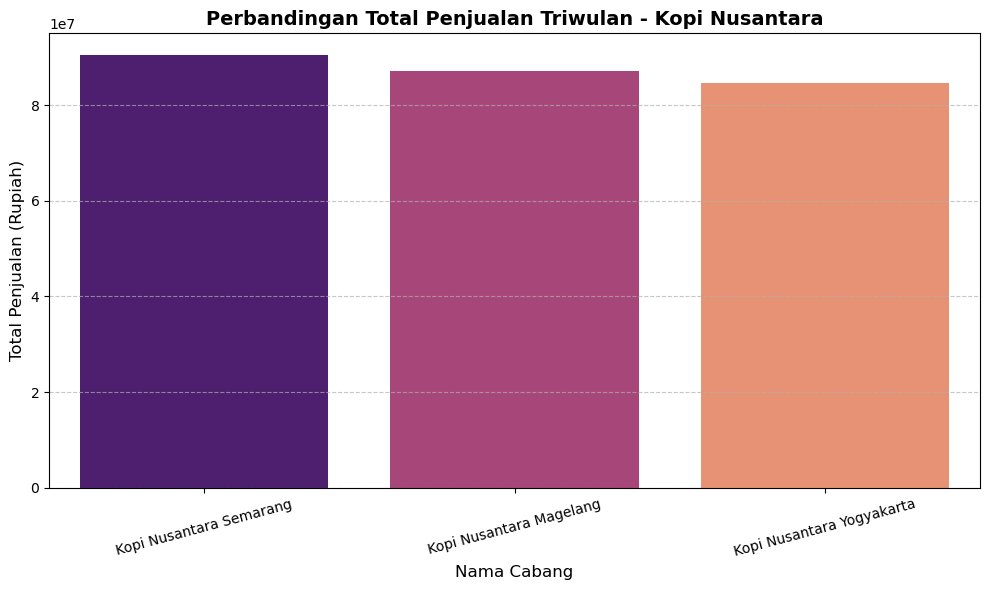

In [10]:
# G. Eksplorasi Tambahan: Visualisasi Performa Penjualan Cabang
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengubah Spark DataFrame yang ukurannya sudah kecil (hasil agregasi) menjadi Pandas DataFrame
# PENTING: .toPandas() hanya boleh dilakukan pada data yang sudah diagregasi/difilter (ukurannya kecil)
pdf_ringkasan = ringkasan_cabang.toPandas()

# 2. Membuat visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=pdf_ringkasan, 
    x="nama_cabang", 
    y="total_penjualan_triwulan", 
    palette="magma",
    hue="nama_cabang",  
    legend=False        
)

# 3. Kustomisasi tampilan grafik
plt.title("Perbandingan Total Penjualan Triwulan - Kopi Nusantara", fontsize=14, fontweight="bold")
plt.xlabel("Nama Cabang", fontsize=12)
plt.ylabel("Total Penjualan (Rupiah)", fontsize=12)
plt.xticks(rotation=15) # Memiringkan teks cabang agar tidak bertumpuk
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:
spark.stop()
print("SparkSession ditutup.")

SparkSession ditutup.
